## AEDC Abuja Customer Churn Prediction Project

 1. Import Libraries
 2. Loading data with Pandas
 3. Descriptive statistics of data
 4. Exploratory Data Analysis (EDA)¶
 5. Feature Engineering
 6. Model Training
 7. Model Evaluation


### 1. IMPORT LIBRARIES    

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
BLUE = "#1E90FF"
YELLOW = "#FFD700"

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.titleweight"] = "bold"

### 2. LOAD DATASET

In [8]:
df = pd.read_csv("aedc_cx_dataset_2500.csv")
df.head()

,Name,Customer_ID,Account_Number,Meter_Number,Age,Location,Income,Purchase_Frequency,Purchase_History,Churn_Status,...,Service_Charge,Debt_Arrears,Previous_Meter_Reading,Current_Meter_Reading,Energy_Consumption,Billing_Cycle,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage
0,Tina Williams,CUST500000,AEDC100000,MTR200000,46,"Gwagwalada, Abuja, Nigeria",56391,11,34149.30,No,...,1374.03,95.31,5674,5709,35,Jun-2025,0.97,8,4.26,323.31
1,Crystal Hill,CUST500001,AEDC100001,MTR200001,50,"Apo, Abuja, Nigeria",47059,7,14923.63,No,...,1377.09,6260.40,2438,2454,16,Mar-2025,0.85,4,11.23,20.00
2,Joy Sanchez,CUST500002,AEDC100002,MTR200002,32,"Maitama, Abuja, Nigeria",30000,9,8351.26,No,...,2305.53,14660.09,2885,2898,13,Feb-2025,0.81,6,16.61,26.15
3,Chelsea Anderson,CUST500003,AEDC100003,MTR200003,36,"Gwagwalada, Abuja, Nigeria",30000,12,20455.28,No,...,1178.20,14752.71,6881,6900,19,Feb-2025,0.84,5,12.96,269.80
4,Christina Serrano,CUST500004,AEDC100004,MTR200004,42,"Lugbe, Abuja, Nigeria",72897,11,26725.03,No,...,1060.13,27326.15,4061,4091,30,May-2025,0.94,5,5.12,383.67


#### CHECK DATASET SIZE

In [11]:
df.shape

(2500, 33)

2,500 customer records

33 variables/features

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Name                           2500 non-null   object 
 1   Customer_ID                    2500 non-null   object 
 2   Account_Number                 2500 non-null   object 
 3   Meter_Number                   2500 non-null   object 
 4   Age                            2500 non-null   int64  
 5   Location                       2500 non-null   object 
 6   Income                         2500 non-null   int64  
 7   Purchase_Frequency             2500 non-null   int64  
 8   Purchase_History               2500 non-null   float64
 9   Churn_Status                   2500 non-null   object 
 10  Customer_Satisfaction_Score    2500 non-null   float64
 11  Average_Resolution_Time_Hours  2500 non-null   float64
 12  Complaint_Frequency            2500 non-null   i

This shows:

Which columns are numeric vs categorical, and show Token has missing values.

### 3.SUMMARY STATISTICS

In [18]:
df.describe()

,Age,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Amount_Paid,Units_Purchased,VAT,Service_Charge,Debt_Arrears,Previous_Meter_Reading,Current_Meter_Reading,Energy_Consumption,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,37.367600,76404.922000,7.561600,52198.011572,3.860920,30.511948,2.162400,6615.548384,77.180080,496.166048,1385.812092,20609.213688,4557.558000,4634.237200,76.679200,0.913564,4.620800,8.030008,577.654340
std,10.680473,57017.905218,2.887064,53770.627004,0.668483,11.449663,2.019915,6220.547196,77.258257,466.541098,625.068999,17090.540515,2015.906283,2014.532042,77.255196,0.057202,2.804595,6.227612,603.667622
min,18.000000,30000.000000,1.000000,1077.010000,1.270000,2.000000,0.000000,673.530000,5.490000,50.510000,300.010000,20.690000,1001.000000,1016.000000,5.000000,0.720000,0.000000,0.000000,20.000000
25%,30.000000,36167.750000,6.000000,20087.940000,3.430000,22.677500,0.000000,2871.530000,31.322500,215.367500,843.462500,8432.132500,2864.750000,2947.500000,31.000000,0.870000,3.000000,3.140000,204.867500
50%,37.000000,59873.500000,8.000000,35385.040000,3.950000,30.175000,2.000000,4682.450000,54.180000,351.185000,1386.055000,17335.665000,4515.000000,4604.000000,54.000000,0.910000,5.000000,6.750000,382.290000
75%,45.000000,93790.500000,10.000000,66867.642500,4.420000,38.172500,4.000000,8392.907500,96.817500,629.470000,1919.710000,26508.595000,6316.500000,6383.750000,96.000000,0.960000,7.000000,11.562500,730.487500
max,65.000000,671936.000000,15.000000,871446.650000,4.980000,68.590000,10.000000,114160.220000,1403.340000,8562.020000,2499.700000,79803.380000,7997.000000,8382.000000,1403.000000,1.000000,15.000000,36.140000,5000.000000


#### CHECK DUPLICATE RECORDS

In [24]:
df.duplicated().sum()

0

#### DATA CLEANING: HANDLING MISSING VALUES
##### CHECK MISSING VALUES COUNT

In [27]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

Token                            1242
Name                                0
Meter_Type                          0
Power_Outage_Duration_Hours         0
Power_Outage_Frequency              0
Billing_Accuracy                    0
Billing_Cycle                       0
Energy_Consumption                  0
Current_Meter_Reading               0
Previous_Meter_Reading              0
Debt_Arrears                        0
Service_Charge                      0
VAT                                 0
Units_Purchased                     0
Amount_Paid                         0
Tariff_Class                        0
Payment_Type                        0
Customer_ID                         0
Receipt_Number                      0
Transaction_Reference               0
Transaction_DateTime                0
Complaint_Frequency                 0
Average_Resolution_Time_Hours       0
Customer_Satisfaction_Score         0
Churn_Status                        0
Purchase_History                    0
Purchase_Fre

This shows missing values column by column.

Token has many missing values, which is normal because:

Postpaid customers do not require STS token.

#### CONVERT TRANSACTION DATETIME

In [33]:
df["Transaction_DateTime"] = pd.to_datetime(df["Transaction_DateTime"])

df["Year"] = df["Transaction_DateTime"].dt.year
df["Month"] = df["Transaction_DateTime"].dt.month
df["Month_Name"] = df["Transaction_DateTime"].dt.month_name()

df.head()

,Name,Customer_ID,Account_Number,Meter_Number,Age,Location,Income,Purchase_Frequency,Purchase_History,Churn_Status,...,Current_Meter_Reading,Energy_Consumption,Billing_Cycle,Billing_Accuracy,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage,Year,Month,Month_Name
0,Tina Williams,CUST500000,AEDC100000,MTR200000,46,"Gwagwalada, Abuja, Nigeria",56391,11,34149.30,No,...,5709,35,Jun-2025,0.97,8,4.26,323.31,2025,8,August
1,Crystal Hill,CUST500001,AEDC100001,MTR200001,50,"Apo, Abuja, Nigeria",47059,7,14923.63,No,...,2454,16,Mar-2025,0.85,4,11.23,20.00,2026,1,January
2,Joy Sanchez,CUST500002,AEDC100002,MTR200002,32,"Maitama, Abuja, Nigeria",30000,9,8351.26,No,...,2898,13,Feb-2025,0.81,6,16.61,26.15,2025,5,May
3,Chelsea Anderson,CUST500003,AEDC100003,MTR200003,36,"Gwagwalada, Abuja, Nigeria",30000,12,20455.28,No,...,6900,19,Feb-2025,0.84,5,12.96,269.80,2025,11,November
4,Christina Serrano,CUST500004,AEDC100004,MTR200004,42,"Lugbe, Abuja, Nigeria",72897,11,26725.03,No,...,4091,30,May-2025,0.94,5,5.12,383.67,2026,3,March


Now we can analyze:

monthly consumption,
yearly trends,
forecasting

### 3. EXPLORATORY DATA ANALYSIS (EDA)

#### CHURN DISTRIBUTION

In [41]:
df["Churn_Status"].value_counts()

Churn_Status
No     1936
Yes     564
Name: count, dtype: int64

In [43]:
df["Churn_Status"].value_counts(normalize=True) * 100

Churn_Status
No     77.44
Yes    22.56
Name: proportion, dtype: float64

#### CHURN DISTRIBUTION PLOT

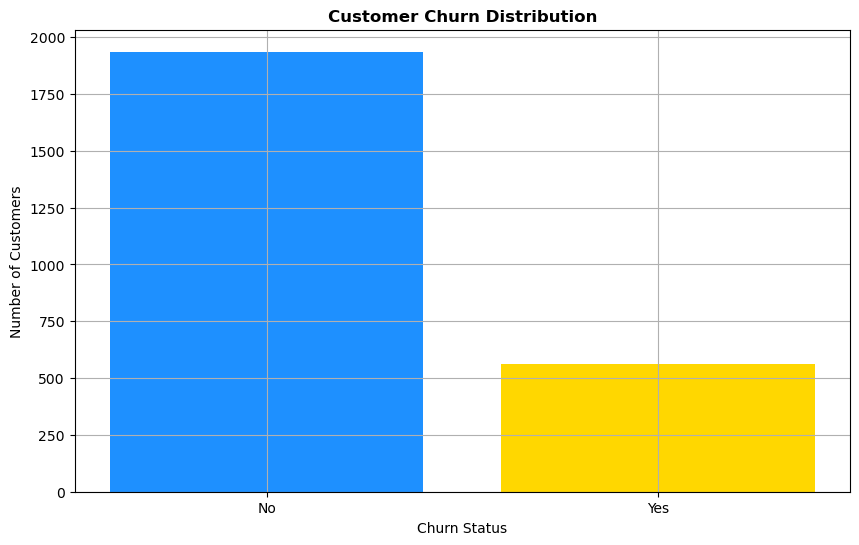

In [46]:
churn_counts = df["Churn_Status"].value_counts()

plt.bar(churn_counts.index, churn_counts.values, color=[BLUE, YELLOW])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

AEDC retains most customers that is why "No" is much higher than "Yes".

#### INCOME DISTRIBUTION

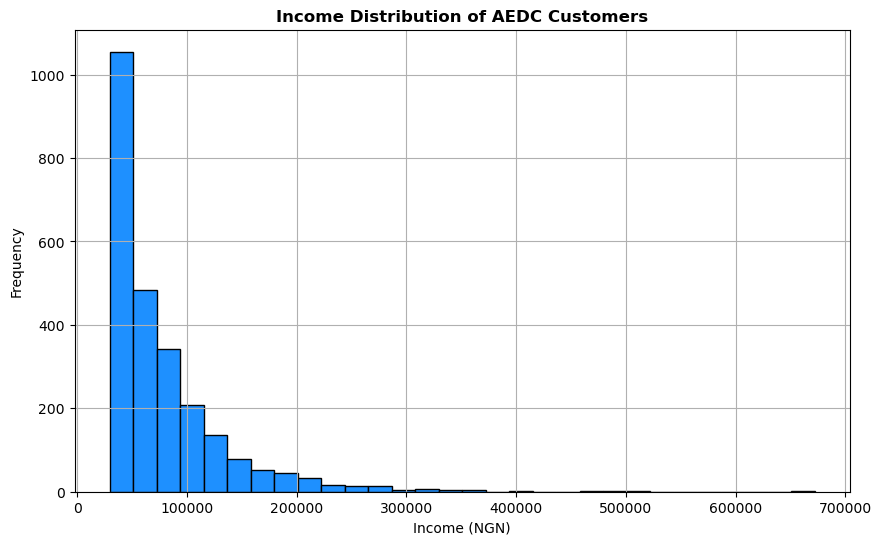

In [51]:
plt.hist(df["Income"], bins=30, color=BLUE, edgecolor="black")
plt.title("Income Distribution of AEDC Customers")
plt.xlabel("Income (NGN)")
plt.ylabel("Frequency")
plt.show()

Income is right-skewed:

many low/middle-income customers and
few high-income customers

#### PURCHASE HISTORY DISTRIBUTION

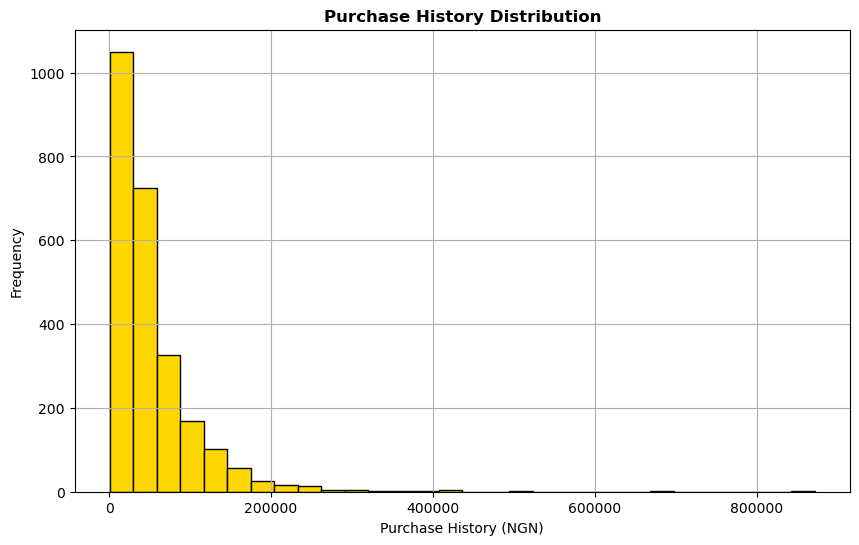

In [55]:
plt.hist(df["Purchase_History"], bins=30, color=YELLOW, edgecolor="black")
plt.title("Purchase History Distribution")
plt.xlabel("Purchase History (NGN)")
plt.ylabel("Frequency")
plt.show()

High purchase history indicates high-value customers

purchase history depends on income and usage

#### OUTAGE FREQUENCY DISTRIBUTION

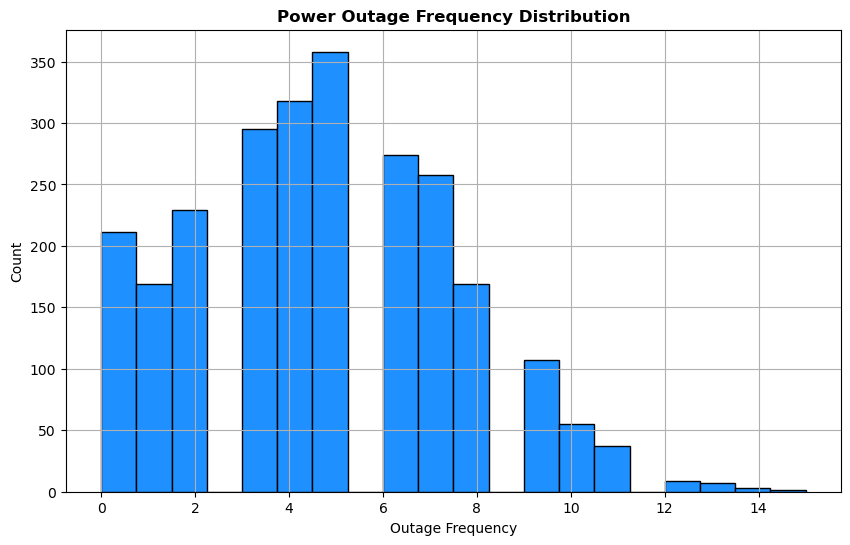

In [60]:
plt.hist(df["Power_Outage_Frequency"], bins=20, color=BLUE, edgecolor="black")
plt.title("Power Outage Frequency Distribution")
plt.xlabel("Outage Frequency")
plt.ylabel("Count")
plt.show()

customers with frequent outages are more likely to churn

#### OUTAGE DURATION DISTRIBUTION

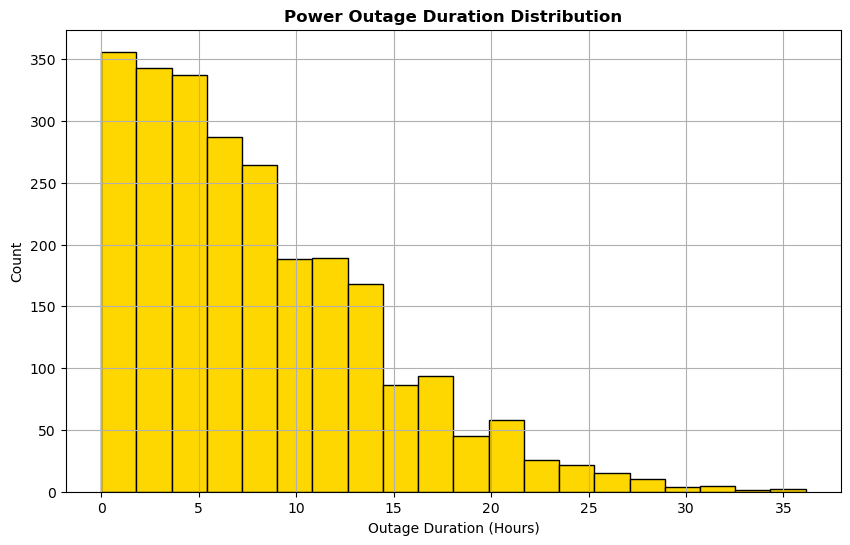

In [64]:
plt.hist(df["Power_Outage_Duration_Hours"], bins=20, color=YELLOW, edgecolor="black")
plt.title("Power Outage Duration Distribution")
plt.xlabel("Outage Duration (Hours)")
plt.ylabel("Count")
plt.show()

#### SERVICE USAGE DISTRIBUTION

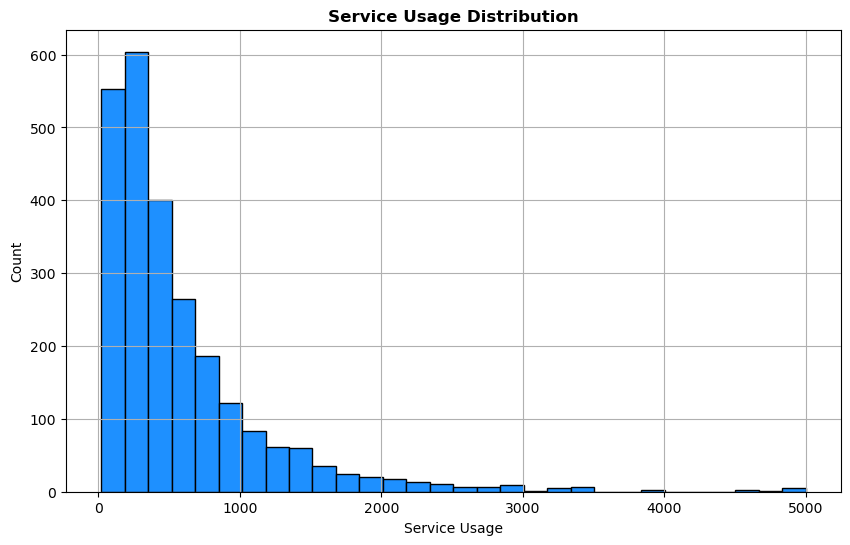

In [67]:
plt.hist(df["Service_Usage"], bins=30, color=BLUE, edgecolor="black")
plt.title("Service Usage Distribution")
plt.xlabel("Service Usage")
plt.ylabel("Count")
plt.show()

higher service usage = higher electricity demand

high usage customers are valuable and should be retained

#### SATISFACTION SCORE DISTRIBUTION

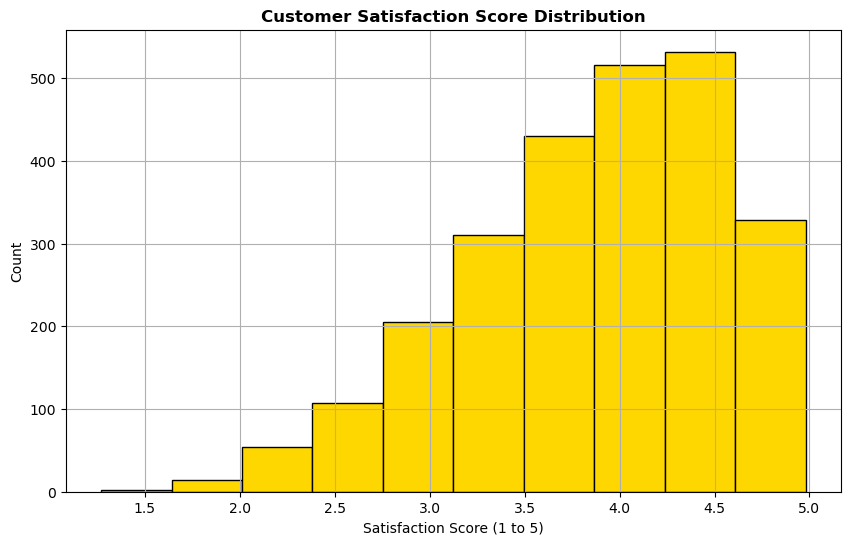

In [72]:
plt.hist(df["Customer_Satisfaction_Score"], bins=10, color=YELLOW, edgecolor="black")
plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score (1 to 5)")
plt.ylabel("Count")
plt.show()

Scores closer to 5 mean satisfied customers

scores closer to 1 indicate dissatisfaction and churn risk

#### COMPLAINT FREQUENCY DISTRIBUTION

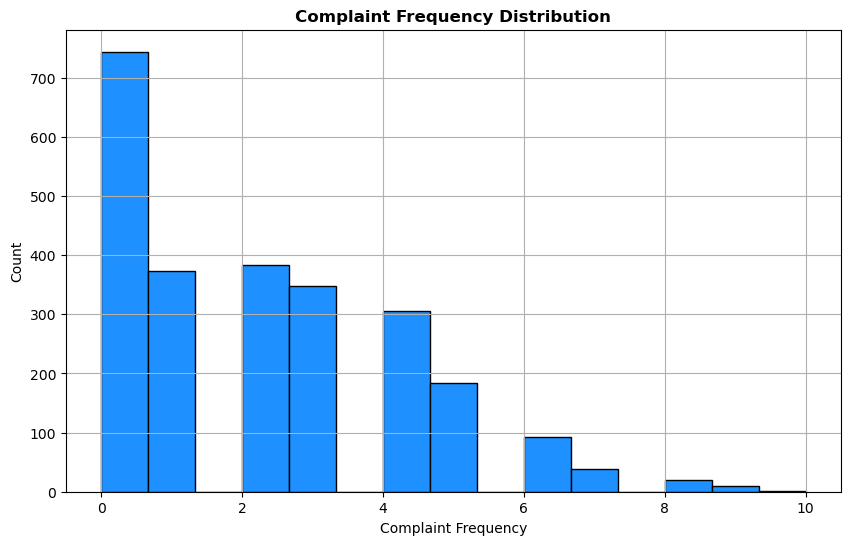

In [76]:
plt.hist(df["Complaint_Frequency"], bins=15, color=BLUE, edgecolor="black")
plt.title("Complaint Frequency Distribution")
plt.xlabel("Complaint Frequency")
plt.ylabel("Count")
plt.show()

Customers with frequent complaints are likely unhappy and may churn.

#### RESOLUTION TIME DISTRIBUTION

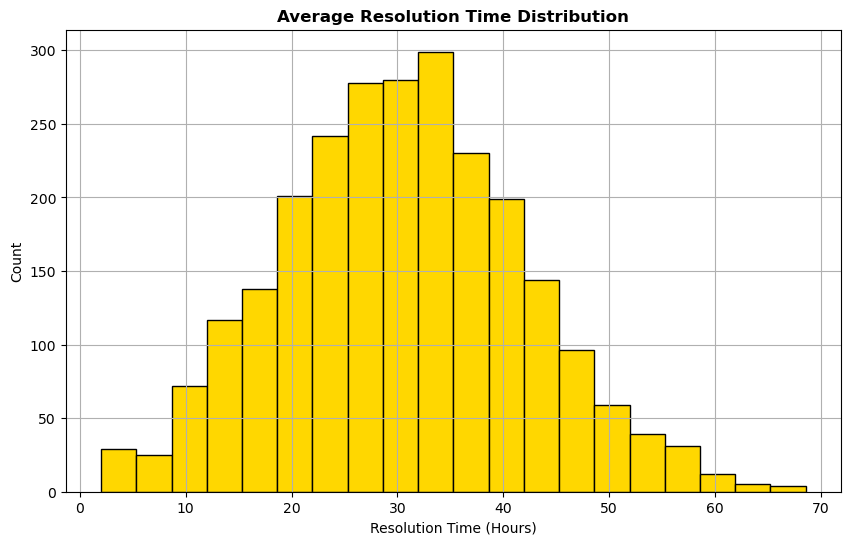

In [80]:
plt.hist(df["Average_Resolution_Time_Hours"], bins=20, color=YELLOW, edgecolor="black")
plt.title("Average Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Count")
plt.show()

Longer resolution time suggests poor customer support and affects satisfaction.

### CHURN VS KEY FEATURES

#### CHURN VS INCOME

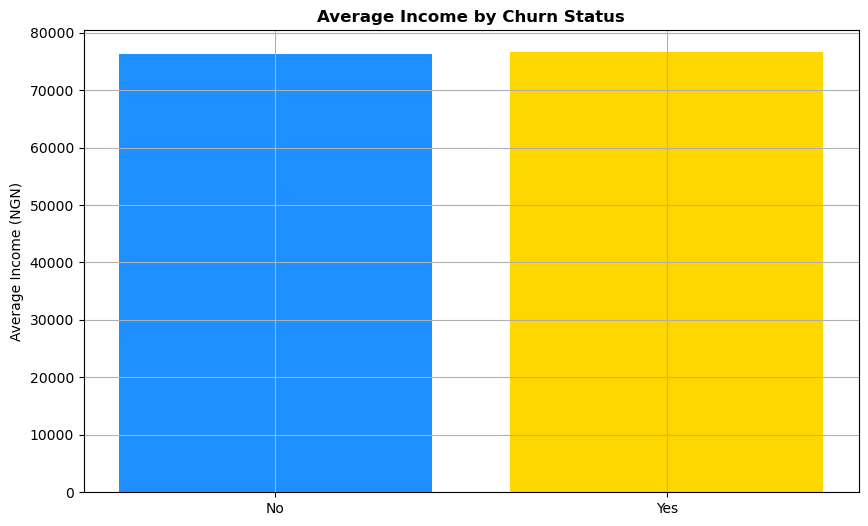

Churn_Status
No     76353.816632
Yes    76580.347518
Name: Income, dtype: float64

In [85]:
income_churn = df.groupby("Churn_Status")["Income"].mean()

plt.bar(income_churn.index, income_churn.values, color=[BLUE, YELLOW])
plt.title("Average Income by Churn Status")
plt.ylabel("Average Income (NGN)")
plt.show()

income_churn

If churned customers earn less:

affordability and payment difficulty drives churn.

#### CHURN VS PURCHASE HISTORY

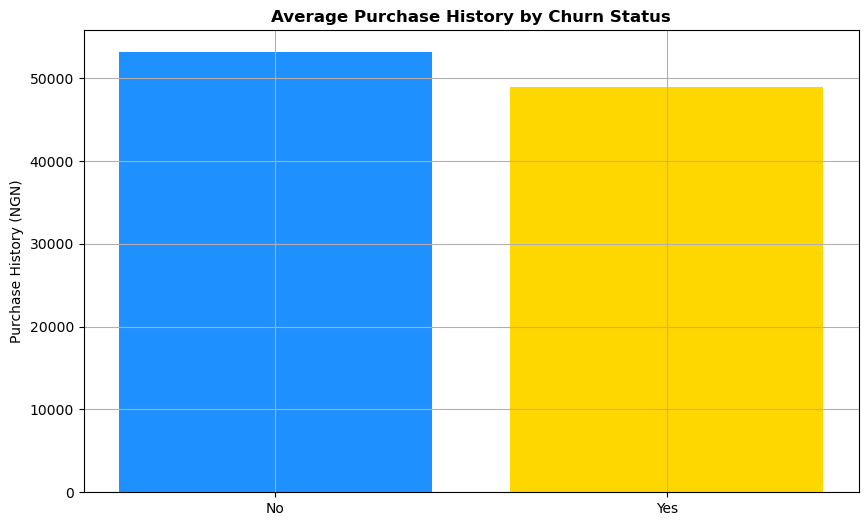

Churn_Status
No     53150.952965
Yes    48926.921968
Name: Purchase_History, dtype: float64

In [89]:
purchase_churn = df.groupby("Churn_Status")["Purchase_History"].mean()

plt.bar(purchase_churn.index, purchase_churn.values, color=[BLUE, YELLOW])
plt.title("Average Purchase History by Churn Status")
plt.ylabel("Purchase History (NGN)")
plt.show()

purchase_churn

Low purchase history customers tend to churn because they are less engaged.

#### CHURN VS OUTAGE FREQUENCY

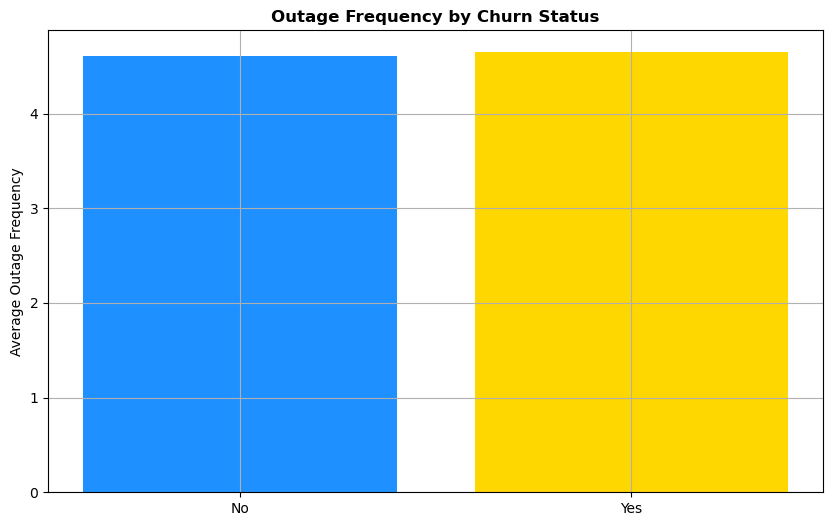

Churn_Status
No     4.613120
Yes    4.647163
Name: Power_Outage_Frequency, dtype: float64

In [93]:
outage_churn = df.groupby("Churn_Status")["Power_Outage_Frequency"].mean()

plt.bar(outage_churn.index, outage_churn.values, color=[BLUE, YELLOW])
plt.title("Outage Frequency by Churn Status")
plt.ylabel("Average Outage Frequency")
plt.show()

outage_churn

If churn customers experience higher outages, reliability is a churn driver.

### ENERGY CONSUMPTION ANALYSIS (MONTHLY & YEARLY)

#### CONSUMPTION DISTRIBUTION

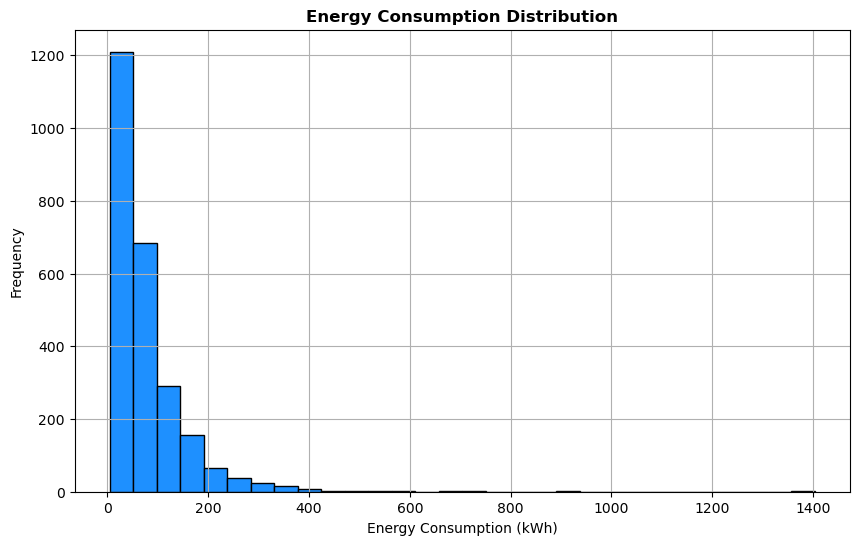

In [98]:
plt.hist(df["Energy_Consumption"], bins=30, color=BLUE, edgecolor="black")
plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

Shows:

typical household usage

high usage customers (commercial)

#### MONTHLY CONSUMPTION TREND

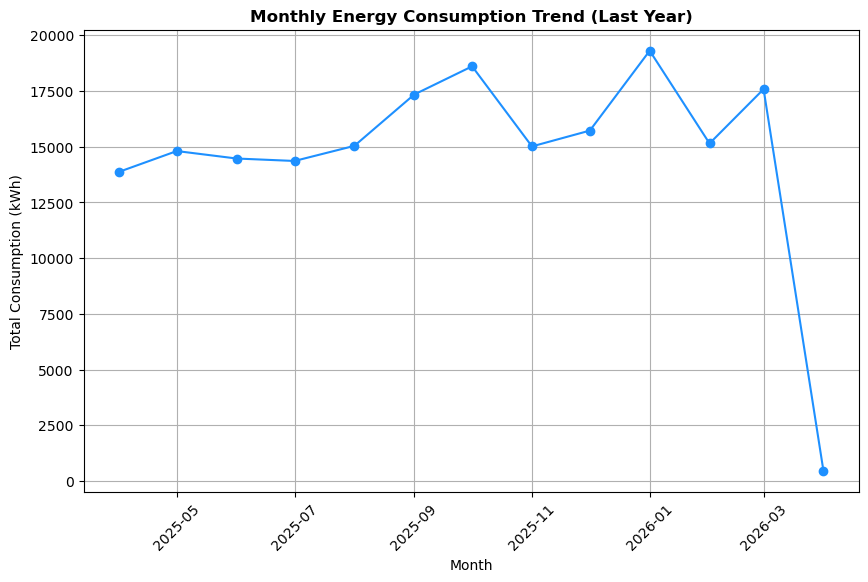

,Year,Month,Energy_Consumption,Date
0,2025,4,13868,2025-04-01
1,2025,5,14803,2025-05-01
2,2025,6,14468,2025-06-01
3,2025,7,14358,2025-07-01
4,2025,8,15036,2025-08-01
5,2025,9,17338,2025-09-01
6,2025,10,18603,2025-10-01
7,2025,11,15011,2025-11-01
8,2025,12,15721,2025-12-01
9,2026,1,19303,2026-01-01


In [102]:
monthly_consumption = df.groupby(["Year","Month"])["Energy_Consumption"].sum().reset_index()

monthly_consumption["Date"] = pd.to_datetime(
    monthly_consumption["Year"].astype(str) + "-" + monthly_consumption["Month"].astype(str)
)

plt.plot(monthly_consumption["Date"], monthly_consumption["Energy_Consumption"], color=BLUE, marker="o")
plt.title("Monthly Energy Consumption Trend (Last Year)")
plt.xlabel("Month")
plt.ylabel("Total Consumption (kWh)")
plt.xticks(rotation=45)
plt.show()

monthly_consumption

Shows consumption demand variation across the year.

### FORECASTING CONSUMPTION

#### MOVING AVERAGE FORECAST (3 MONTHS)

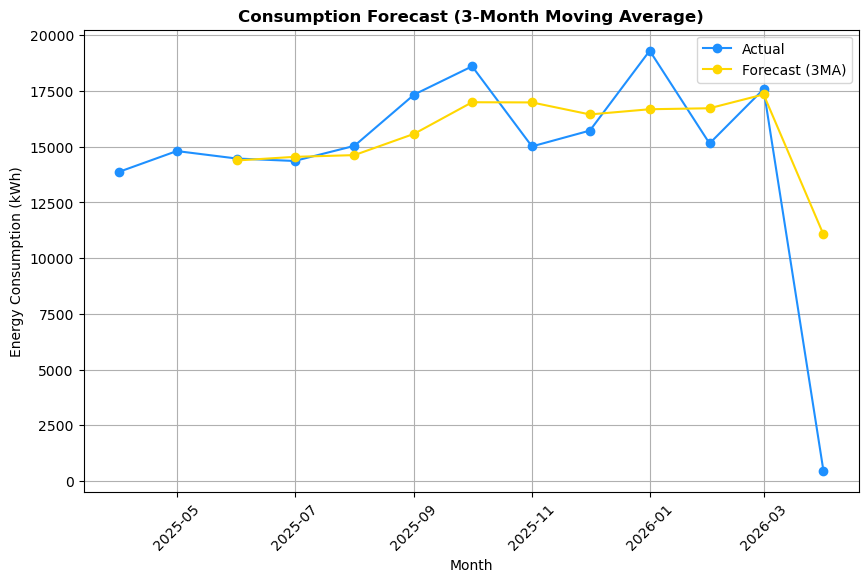

In [107]:
monthly_consumption["Forecast_3MA"] = monthly_consumption["Energy_Consumption"].rolling(3).mean()

plt.plot(monthly_consumption["Date"], monthly_consumption["Energy_Consumption"], color=BLUE, marker="o", label="Actual")
plt.plot(monthly_consumption["Date"], monthly_consumption["Forecast_3MA"], color=YELLOW, marker="o", label="Forecast (3MA)")

plt.title("Consumption Forecast (3-Month Moving Average)")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

The forecast line smoothens fluctuations and predicts expected future consumption.

### MARGIN ANALYSIS

#### CALCULATE MARGINS
Assume cost per kWh = ₦225

In [113]:
df["Estimated_Cost"] = df["Units_Purchased"] * 225
df["Margin"] = df["Amount_Paid"] - df["Estimated_Cost"]

df[["Amount_Paid","Units_Purchased","Estimated_Cost","Margin"]].head()

,Amount_Paid,Units_Purchased,Estimated_Cost,Margin
0,3614.02,35.84,8064.00,-4449.98
1,1994.74,16.67,3750.75,-1756.01
2,1060.22,13.72,3087.00,-2026.78
3,1526.15,19.27,4335.75,-2809.60
4,2506.17,30.37,6833.25,-4327.08


Interpretation

Margin > 0 = profit customer

Margin < 0 = loss customer

#### MARGIN DISTRIBUTION

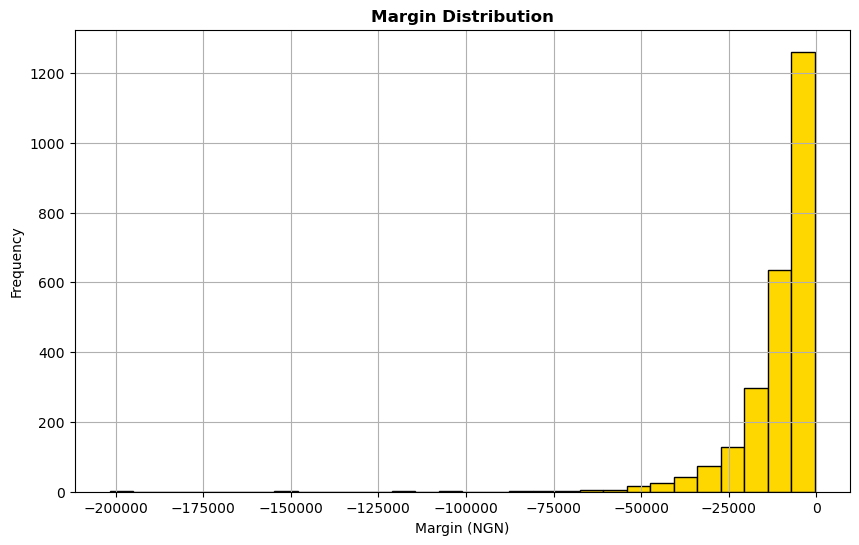

In [116]:
plt.hist(df["Margin"], bins=30, color=YELLOW, edgecolor="black")
plt.title("Margin Distribution")
plt.xlabel("Margin (NGN)")
plt.ylabel("Frequency")
plt.show()

Helps AEDC identify profitability distribution.

### SUBSCRIBED POWER ESTIMATION

#### CREATE SUBSCRIBED POWER FEATURE

In [125]:
df["Subscribed_Power_kVA"] = np.where(df["Service_Usage"] > 2000, 15,
                             np.where(df["Service_Usage"] > 1200, 10,
                             np.where(df["Service_Usage"] > 700, 5, 2)))

df["Subscribed_Power_kVA"].value_counts()

Subscribed_Power_kVA
2     1841
5      384
10     188
15      87
Name: count, dtype: int64

#### SUBSCRIBED POWER VISUALIZATION

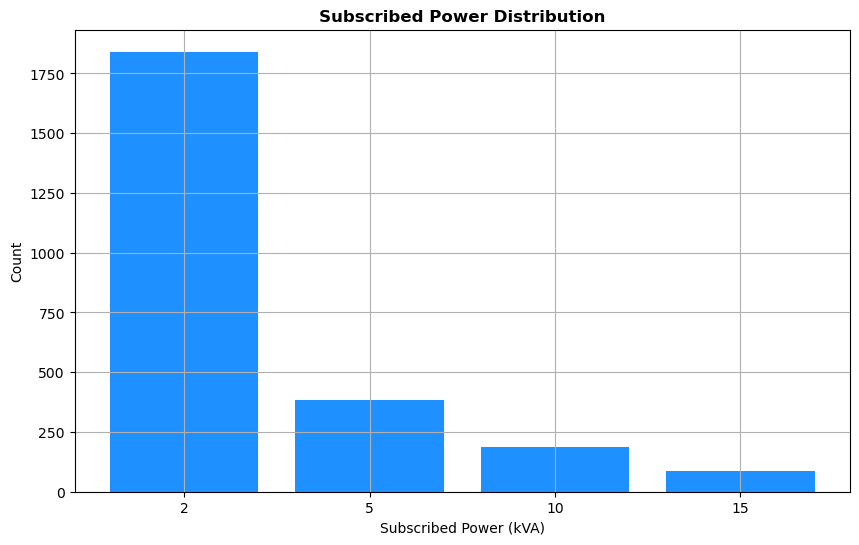

In [128]:
sub_counts = df["Subscribed_Power_kVA"].value_counts()

plt.bar(sub_counts.index.astype(str), sub_counts.values, color=BLUE)
plt.title("Subscribed Power Distribution")
plt.xlabel("Subscribed Power (kVA)")
plt.ylabel("Count")
plt.show()

Shows customer segmentation:

2kVA = small household

15kVA = business/high-value

#### CORRELATION HEATMAP

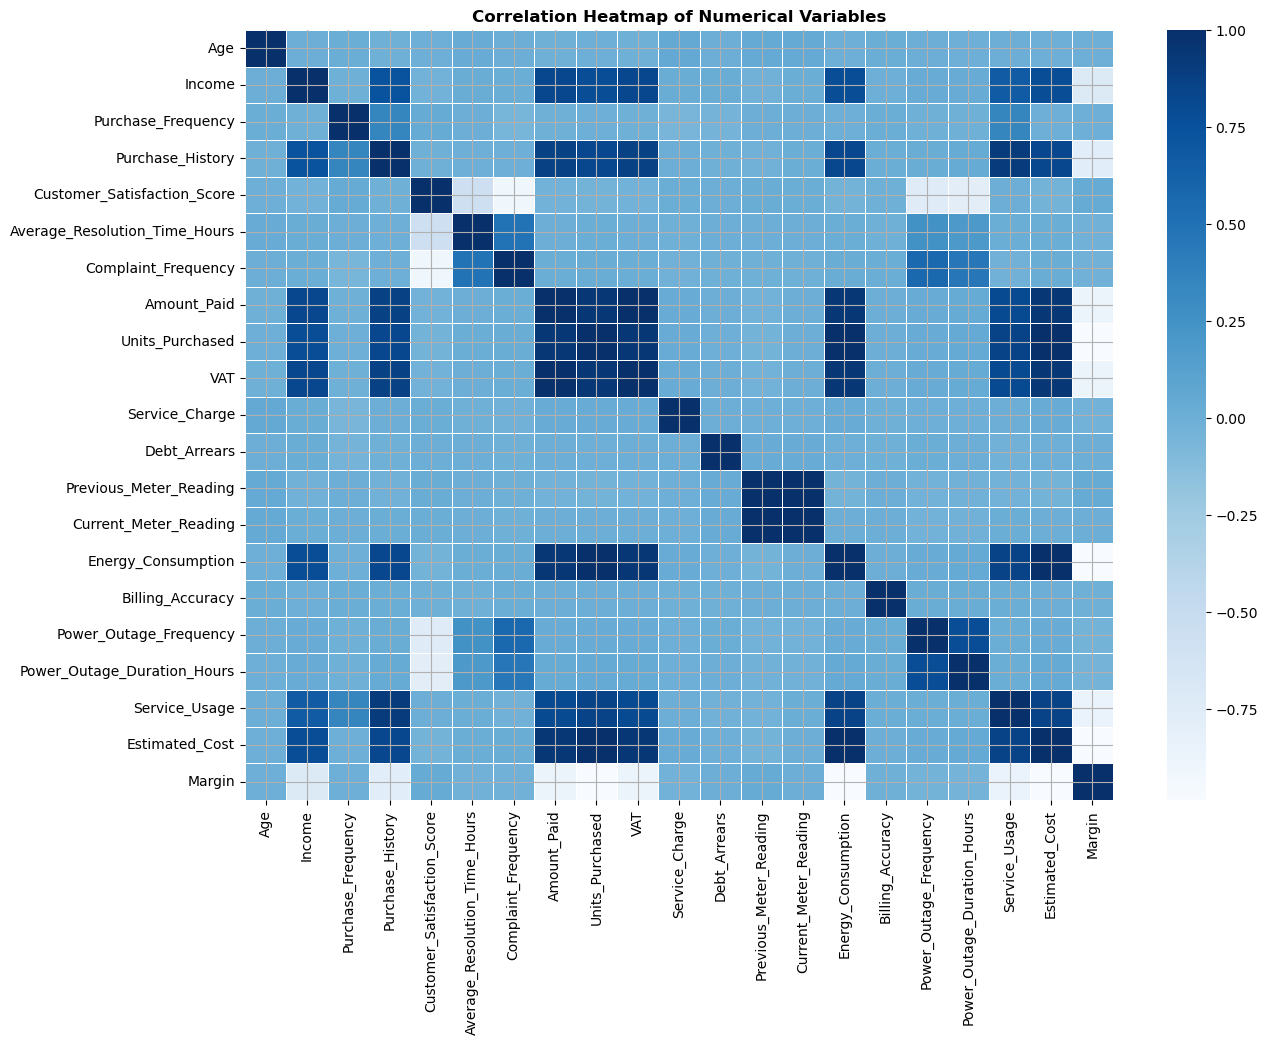

In [132]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(corr, cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Strong correlations:

Income ↔ Purchase History

Outage Duration ↔ Complaints

Satisfaction ↔ Complaints (negative)

### FEATURE ENGINEERING FOR MACHINE LEARNING

#### TARGET VARIABLE ENCODING

In [137]:
df["Churn"] = df["Churn_Status"].map({"No":0, "Yes":1})
df["Churn"].value_counts()

Churn
0    1936
1     564
Name: count, dtype: int64

This converts churn into numeric form for modelling:

0 = Active

1 = Churned

#### DROP IRRELEVANT COLUMNS

In [141]:
df_model = df.drop(columns=[
    "Name","Customer_ID","Account_Number","Meter_Number",
    "Transaction_Reference","Receipt_Number","Token",
    "Transaction_DateTime","Churn_Status"
])

df_model.head()

,Age,Location,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Payment_Type,Meter_Type,...,Power_Outage_Frequency,Power_Outage_Duration_Hours,Service_Usage,Year,Month,Month_Name,Estimated_Cost,Margin,Subscribed_Power_kVA,Churn
0,46,"Gwagwalada, Abuja, Nigeria",56391,11,34149.30,3.88,30.50,3,Mobile App,Postpaid,...,8,4.26,323.31,2025,8,August,8064.00,-4449.98,2,0
1,50,"Apo, Abuja, Nigeria",47059,7,14923.63,3.72,32.35,2,Cash,Prepaid,...,4,11.23,20.00,2026,1,January,3750.75,-1756.01,2,0
2,32,"Maitama, Abuja, Nigeria",30000,9,8351.26,3.55,22.16,2,POS,Postpaid,...,6,16.61,26.15,2025,5,May,3087.00,-2026.78,2,0
3,36,"Gwagwalada, Abuja, Nigeria",30000,12,20455.28,4.04,31.03,0,POS,Postpaid,...,5,12.96,269.80,2025,11,November,4335.75,-2809.60,2,0
4,42,"Lugbe, Abuja, Nigeria",72897,11,26725.03,4.49,25.54,0,Transfer,Postpaid,...,5,5.12,383.67,2026,3,March,6833.25,-4327.08,2,0


These are dropped because:

IDs do not help prediction

prevents leakage and noise

#### ONE-HOT ENCODING CATEGORICAL COLUMNS

In [145]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,Age,Income,Purchase_Frequency,Purchase_History,Customer_Satisfaction_Score,Average_Resolution_Time_Hours,Complaint_Frequency,Amount_Paid,Units_Purchased,VAT,...,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September
0,46,56391,11,34149.30,3.88,30.50,3,3614.02,35.84,271.05,...,False,False,False,False,False,False,False,False,False,False
1,50,47059,7,14923.63,3.72,32.35,2,1994.74,16.67,149.61,...,False,False,True,False,False,False,False,False,False,False
2,32,30000,9,8351.26,3.55,22.16,2,1060.22,13.72,79.52,...,False,False,False,False,False,False,True,False,False,False
3,36,30000,12,20455.28,4.04,31.03,0,1526.15,19.27,114.46,...,False,False,False,False,False,False,False,True,False,False
4,42,72897,11,26725.03,4.49,25.54,0,2506.17,30.37,187.96,...,False,False,False,False,False,True,False,False,False,False


This converts text columns into numeric binary columns.

### MODELLING

### TRAIN TEST SPLIT

In [150]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train set = model learns patterns

Test set = evaluates real-world performance

### LOGISTIC REGRESSION

#### SCALE DATA (REQUIRED)

In [156]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### TRAIN LOGISTIC REGRESSION

In [159]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.908

Confusion Matrix:
 [[386   0]
 [ 46  68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       386
           1       1.00      0.60      0.75       114

    accuracy                           0.91       500
   macro avg       0.95      0.80      0.85       500
weighted avg       0.92      0.91      0.90       500



Logistic Regression is a baseline model.

It helps interpret churn probability linearly.

#### CONFUSION MATRIX PLOT

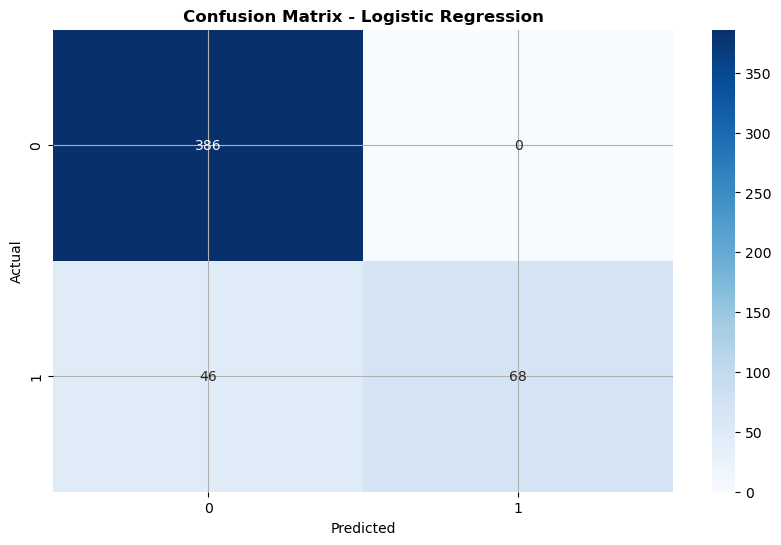

In [164]:
cm_log = confusion_matrix(y_test, log_pred)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

True Positives = correctly predicted churn

False Negatives = churn missed (dangerous)

### RANDOM FOREST

#### TRAIN RANDOM FOREST

In [170]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.928

Confusion Matrix:
 [[386   0]
 [ 36  78]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.96       386
           1       1.00      0.68      0.81       114

    accuracy                           0.93       500
   macro avg       0.96      0.84      0.88       500
weighted avg       0.93      0.93      0.92       500



#### CONFUSION MATRIX RANDOM FOREST

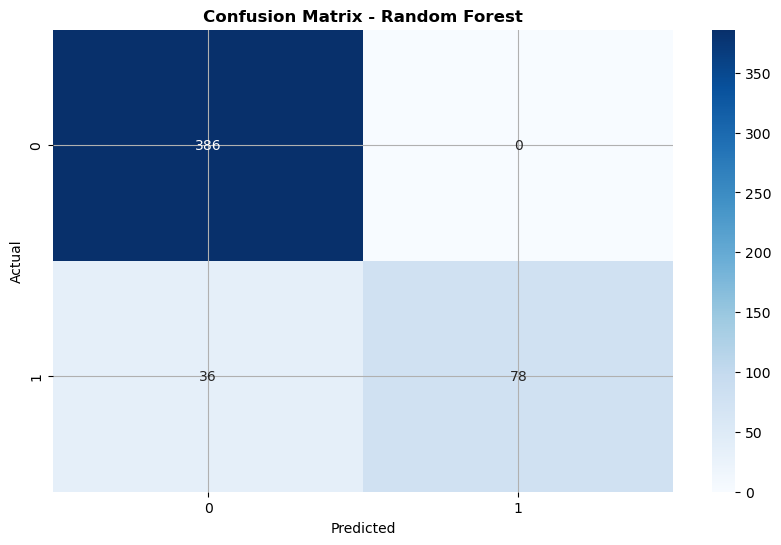

In [173]:
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### MODEL UNDERSTANDING: FEATURE IMPORTANCE

##### FEATURE IMPORTANCE

In [177]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10)

Debt_Arrears                     0.431089
Previous_Meter_Reading           0.028955
Average_Resolution_Time_Hours    0.028831
Service_Charge                   0.028700
Current_Meter_Reading            0.027697
Purchase_History                 0.027217
Service_Usage                    0.024848
Margin                           0.024424
Power_Outage_Duration_Hours      0.024186
VAT                              0.024150
dtype: float64

#### PLOT TOP 10 IMPORTANT FEATURES

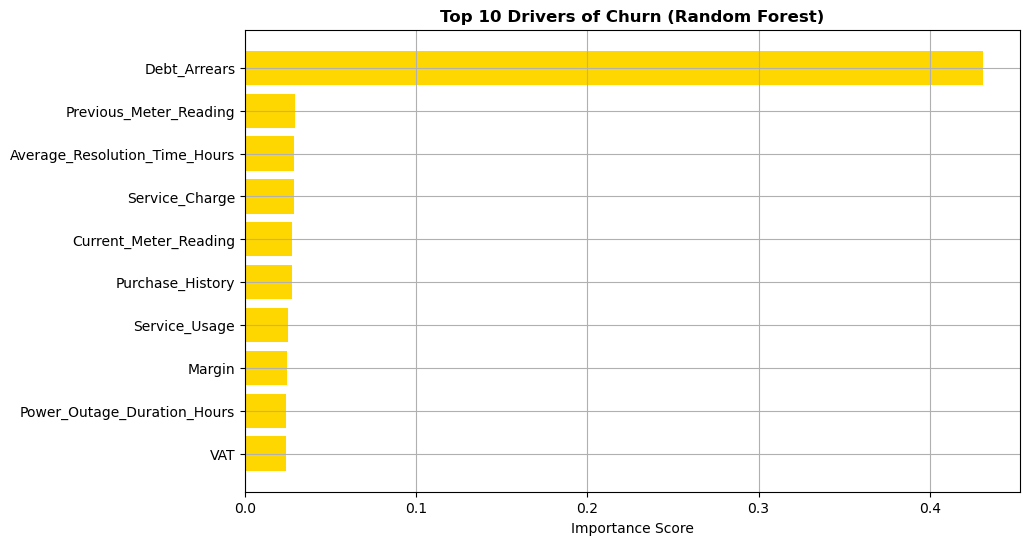

In [180]:
top10 = importances.head(10)

plt.barh(top10.index, top10.values, color=YELLOW)
plt.title("Top 10 Drivers of Churn (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

The model reveals key churn drivers such as:

Satisfaction score

Complaint frequency

Outage duration

Debt/arrears

Resolution time

#### ROC CURVE + AUC SCORE

##### ROC CURVE FOR RANDOM FOREST

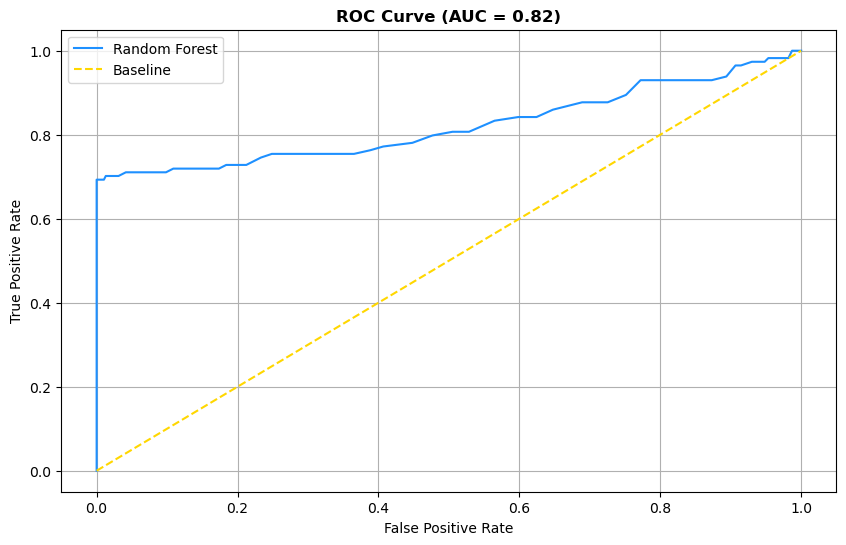

In [187]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, rf_prob)

fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr, color=BLUE, label="Random Forest")
plt.plot([0,1], [0,1], color=YELLOW, linestyle="--", label="Baseline")

plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

AUC closer to 1 means excellent churn model.
    
AUC > 0.70 is good for business data.

### PROACTIVE RETENTION STRATEGY

#### PREDICT CHURN PROBABILITY FOR ALL CUSTOMERS

In [192]:
df["Churn_Probability"] = rf_model.predict_proba(X)[:, 1]
df[["Customer_ID","Location","Churn_Probability"]].head()

,Customer_ID,Location,Churn_Probability
0,CUST500000,"Gwagwalada, Abuja, Nigeria",0.043333
1,CUST500001,"Apo, Abuja, Nigeria",0.076667
2,CUST500002,"Maitama, Abuja, Nigeria",0.090000
3,CUST500003,"Gwagwalada, Abuja, Nigeria",0.060000
4,CUST500004,"Lugbe, Abuja, Nigeria",0.036667


#### CLASSIFY CUSTOMER RISK LEVELS

In [195]:
df["Risk_Level"] = pd.cut(df["Churn_Probability"],
                          bins=[0, 0.3, 0.6, 1.0],
                          labels=["Low Risk", "Medium Risk", "High Risk"])

df["Risk_Level"].value_counts()

Risk_Level
Low Risk       1963
High Risk       527
Medium Risk      10
Name: count, dtype: int64

#### VISUALIZE CUSTOMER RISK LEVELS

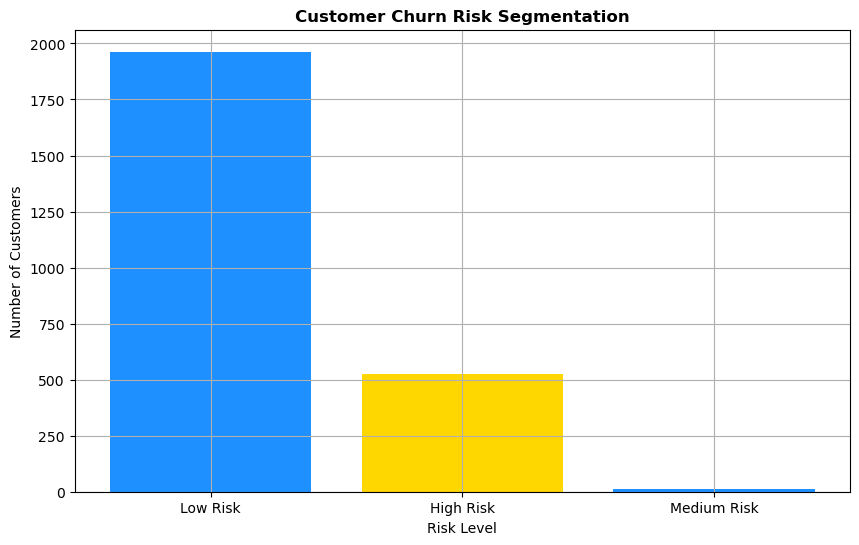

In [198]:
risk_counts = df["Risk_Level"].value_counts()

plt.bar(risk_counts.index, risk_counts.values, color=[BLUE, YELLOW, BLUE])
plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()

Interpretation

High risk customers should be targeted for retention campaigns.
    
Medium risk customers need monitoring.

Low risk customers are stable.

#### TOP 20 HIGH-RISK CUSTOMERS

In [202]:
high_risk_customers = df[df["Risk_Level"] == "High Risk"].sort_values("Churn_Probability", ascending=False).head(20)

high_risk_customers[[
    "Customer_ID","Location","Income","Debt_Arrears",
    "Customer_Satisfaction_Score","Complaint_Frequency",
    "Power_Outage_Frequency","Power_Outage_Duration_Hours",
    "Churn_Probability"
]]

,Customer_ID,Location,Income,Debt_Arrears,Customer_Satisfaction_Score,Complaint_Frequency,Power_Outage_Frequency,Power_Outage_Duration_Hours,Churn_Probability
1633,CUST501633,"Wuse, Abuja, Nigeria",113665,74950.32,3.96,2,4,7.30,0.973333
878,CUST500878,"Kurudu, Abuja, Nigeria",33868,75318.33,4.72,0,0,0.00,0.973333
1716,CUST501716,"Dutse, Abuja, Nigeria",82053,69654.56,3.19,5,6,9.13,0.970000
331,CUST500331,"Asokoro, Abuja, Nigeria",98472,54579.77,4.46,0,4,8.36,0.970000
1585,CUST501585,"Karu, Abuja, Nigeria",30000,48158.95,3.96,3,2,2.07,0.970000
588,CUST500588,"Maitama, Abuja, Nigeria",132677,39736.31,3.36,4,4,8.57,0.970000
85,CUST500085,"Karu, Abuja, Nigeria",40157,78665.07,4.61,0,1,1.37,0.970000
1038,CUST501038,"Kurudu, Abuja, Nigeria",58192,46725.51,3.95,2,6,6.41,0.970000
911,CUST500911,"Kubwa, Abuja, Nigeria",30000,77502.18,4.63,0,8,6.37,0.966667
1957,CUST501957,"Kurudu, Abuja, Nigeria",30907,42414.12,4.17,2,4,3.18,0.966667


This table provides the AEDC CX team a list of customers that require urgent intervention.